# Trabalho 10 — Rede Neural Multicamadas (MLP)


## 1. Importação das Bibliotecas

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)  # Reprodutibilidade

## 2. Por que o Perceptron Simples Falha no XOR?

A tabela-verdade do XOR é:

| A | B | Saída (A XOR B) |
|---|---|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

O XOR **não é linearmente separável** — não existe uma linha reta capaz de dividir as classes. Por isso, precisamos de **pelo menos uma camada oculta**.

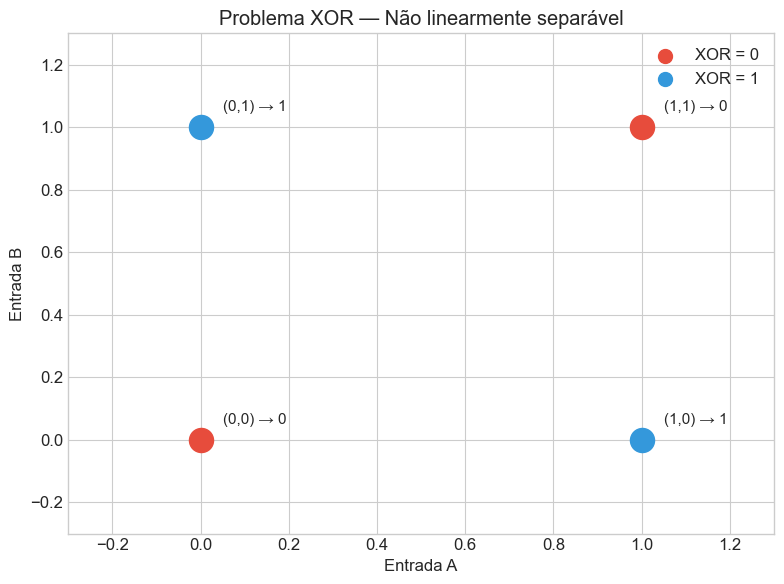

Impossível separar as classes com uma única linha reta!


In [42]:
# Visualizando o problema do XOR
X_xor = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]])

y_xor = np.array([0, 1, 1, 0])

cores = ['#e74c3c' if y == 0 else '#3498db' for y in y_xor]
rotulos = ['XOR=0' if y == 0 else 'XOR=1' for y in y_xor]

fig, ax = plt.subplots()
for i, (x, y, c, r) in enumerate(zip(X_xor, y_xor, cores, rotulos)):
    ax.scatter(x[0], x[1], color=c, s=300, zorder=5,
               label=r if r not in [l.get_label() for l in ax.lines] else "")
    ax.annotate(f'({x[0]},{x[1]}) → {y}', xy=(x[0], x[1]),
                xytext=(x[0]+0.05, x[1]+0.05), fontsize=11)

# Remover legendas duplicadas
handles = [plt.scatter([], [], color='#e74c3c', s=100, label='XOR = 0'),
           plt.scatter([], [], color='#3498db', s=100, label='XOR = 1')]
ax.legend(handles=handles)
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('Entrada A')
ax.set_ylabel('Entrada B')
ax.set_title('Problema XOR — Não linearmente separável')
plt.tight_layout()
plt.show()
print("Impossível separar as classes com uma única linha reta!")

## 3. Implementação da MLP

### Arquitetura
```
Entrada (2 neurônios) -> Camada Oculta (4 neurônios, ReLU) -> Saída (1 neurônio, Sigmoid)
```


In [43]:
class MLP:
    """
    Rede Neural Multicamadas (MLP) implementada apenas com NumPy.

    Arquitetura: Entrada → Camada Oculta (ReLU) → Saída (Sigmoid)

    Parâmetros
    ----------
    n_entrada : int
        Número de neurônios na camada de entrada.
    n_oculta : int
        Número de neurônios na camada oculta.
    n_saida : int
        Número de neurônios na camada de saída.
    taxa_aprendizado : float
        Taxa de aprendizado (eta).
    n_epocas : int
        Número de épocas de treinamento.
    semente : int ou None
        Semente para reprodutibilidade.

    Atributos
    ---------
    W1, b1 : ndarray
        Pesos e bias da camada oculta.
    W2, b2 : ndarray
        Pesos e bias da camada de saída.
    historico_loss_ : list
        Histórico da função de perda (MSE) por época.
    """

    def __init__(self, n_entrada=2, n_oculta=4, n_saida=1,
                 taxa_aprendizado=0.1, n_epocas=10000, semente=42):
        self.n_entrada = n_entrada
        self.n_oculta = n_oculta
        self.n_saida = n_saida
        self.taxa_aprendizado = taxa_aprendizado
        self.n_epocas = n_epocas
        self.semente = semente

    # ──────────────────────────────────────────
    # Funções de Ativação e suas Derivadas
    # ──────────────────────────────────────────

    def _sigmoid(self, z):
        """Função sigmoid: mapeia qualquer valor para (0, 1)."""
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _sigmoid_derivada(self, z):
        """Derivada da sigmoid: σ(z) · (1 - σ(z))."""
        s = self._sigmoid(z)
        return s * (1.0 - s)

    def _relu(self, z):
        """Função ReLU: max(0, z)."""
        return np.maximum(0, z)

    def _relu_derivada(self, z):
        """Derivada da ReLU: 1 se z > 0, senão 0."""
        return np.where(z > 0, 1.0, 0.0)

    # ──────────────────────────────────────────
    # Forward Pass (Propagação Direta)
    # ──────────────────────────────────────────

    def _forward(self, X):
        """
        Passo 1-4: Propaga a entrada pela rede e retorna as ativações.

        Passo 1: z1 = X · W1 + b1  (soma ponderada da camada oculta)
        Passo 2: a1 = ReLU(z1)      (ativação da camada oculta)
        Passo 3: z2 = a1 · W2 + b2  (soma ponderada da camada de saída)
        Passo 4: a2 = Sigmoid(z2)   (ativação da saída = ŷ)
        """
        # Passo 1: Soma ponderada da camada oculta
        z1 = np.dot(X, self.W1) + self.b1

        # Passo 2: Ativação ReLU na camada oculta
        a1 = self._relu(z1)

        # Passo 3: Soma ponderada da camada de saída
        z2 = np.dot(a1, self.W2) + self.b2

        # Passo 4: Ativação Sigmoid na saída
        a2 = self._sigmoid(z2)

        return z1, a1, z2, a2

    # ──────────────────────────────────────────
    # Backward Pass (Retropropagação)
    # ──────────────────────────────────────────

    def _backward(self, X, y, z1, a1, z2, a2):
        """
        Passos 5-8: Calcula os gradientes e atualiza pesos e bias.

        Passo 5: δ2 = (ŷ - y) · Sigmoid'(z2)       (erro na saída)
        Passo 6: δ1 = (δ2 · W2ᵀ) · ReLU'(z1)       (erro na oculta)
        Passo 7: Atualizar W2 e b2
        Passo 8: Atualizar W1 e b1
        """
        n = X.shape[0]
        y = y.reshape(-1, 1)

        # Passo 5: Gradiente da camada de saída
        delta2 = (a2 - y) * self._sigmoid_derivada(z2)

        # Passo 6: Propagação do erro para a camada oculta
        delta1 = np.dot(delta2, self.W2.T) * self._relu_derivada(z1)

        # Passo 7: Atualizar pesos e bias da camada de saída
        self.W2 -= self.taxa_aprendizado * np.dot(a1.T, delta2) / n
        self.b2 -= self.taxa_aprendizado * np.mean(delta2, axis=0)

        # Passo 8: Atualizar pesos e bias da camada oculta
        self.W1 -= self.taxa_aprendizado * np.dot(X.T, delta1) / n
        self.b1 -= self.taxa_aprendizado * np.mean(delta1, axis=0)

    # ──────────────────────────────────────────
    # Função de Perda (MSE)
    # ──────────────────────────────────────────

    def _loss(self, y, y_pred):
        """Erro Quadrático Médio (MSE)."""
        return np.mean((y.reshape(-1, 1) - y_pred) ** 2)

    # ──────────────────────────────────────────
    # Treinamento
    # ──────────────────────────────────────────

    def treinar(self, X, y):
        """
        Treina a MLP com os dados X e rótulos y.

        Parâmetros
        ----------
        X : ndarray, shape (n_amostras, n_features)
        y : ndarray, shape (n_amostras,)

        Retorna
        -------
        self
        """
        rng = np.random.default_rng(self.semente)

        # Inicialização dos pesos (He initialization para ReLU)
        self.W1 = rng.normal(0, np.sqrt(2.0 / self.n_entrada),
                             size=(self.n_entrada, self.n_oculta))
        self.b1 = np.zeros((1, self.n_oculta))

        self.W2 = rng.normal(0, np.sqrt(2.0 / self.n_oculta),
                             size=(self.n_oculta, self.n_saida))
        self.b2 = np.zeros((1, self.n_saida))

        self.historico_loss_ = []

        print(f"Arquitetura: {self.n_entrada} → {self.n_oculta} → {self.n_saida}")
        print(f"Taxa de aprendizado: {self.taxa_aprendizado}")
        print(f"Épocas: {self.n_epocas}")
        print("-" * 45)

        for epoca in range(1, self.n_epocas + 1):
            # Forward pass
            z1, a1, z2, a2 = self._forward(X)

            # Calcular perda
            loss = self._loss(y, a2)
            self.historico_loss_.append(loss)

            # Backward pass
            self._backward(X, y, z1, a1, z2, a2)

            # Log a cada 1000 épocas
            if epoca % 1000 == 0 or epoca == 1:
                print(f"Época {epoca:6d} | Loss (MSE): {loss:.6f}")

        print("-" * 45)
        print(f"Loss final: {self.historico_loss_[-1]:.6f}")
        return self

    # ──────────────────────────────────────────
    # Predição e Avaliação
    # ──────────────────────────────────────────

    def prever_probabilidade(self, X):
        """Retorna a probabilidade de saída (valor contínuo entre 0 e 1)."""
        _, _, _, a2 = self._forward(X)
        return a2

    def prever(self, X, limiar=0.5):
        """Retorna a classe predita (0 ou 1) usando um limiar de decisão."""
        return (self.prever_probabilidade(X) >= limiar).astype(int).flatten()

    def acuracia(self, X, y):
        """Calcula a acurácia do modelo."""
        return np.mean(self.prever(X) == y) * 100

## 4. Dataset XOR

In [44]:
# Tabela verdade do XOR
X_xor = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]], dtype=float)

y_xor = np.array([0, 1, 1, 0], dtype=float)

print("Tabela Verdade XOR:")
print("-" * 25)
print(f"{'A':>5} {'B':>5} {'XOR':>7}")
print("-" * 25)
for (a, b), xor in zip(X_xor, y_xor):
    print(f"{int(a):>5} {int(b):>5} {int(xor):>7}")
print("-" * 25)

Tabela Verdade XOR:
-------------------------
    A     B     XOR
-------------------------
    0     0       0
    0     1       1
    1     0       1
    1     1       0
-------------------------


## 5. Treinamento da MLP

In [45]:
mlp = MLP(
    n_entrada=2,
    n_oculta=4,
    n_saida=1,
    taxa_aprendizado=0.1,
    n_epocas=10000,
    semente=42
)

mlp.treinar(X_xor, y_xor)

Arquitetura: 2 → 4 → 1
Taxa de aprendizado: 0.1
Épocas: 10000
---------------------------------------------
Época      1 | Loss (MSE): 0.264337
Época   1000 | Loss (MSE): 0.173310
Época   2000 | Loss (MSE): 0.149084
Época   3000 | Loss (MSE): 0.060073
Época   4000 | Loss (MSE): 0.021067
Época   5000 | Loss (MSE): 0.010698
Época   6000 | Loss (MSE): 0.006731
Época   7000 | Loss (MSE): 0.004772
Época   8000 | Loss (MSE): 0.003638
Época   9000 | Loss (MSE): 0.002910
Época  10000 | Loss (MSE): 0.002410
---------------------------------------------
Loss final: 0.002410


## 6. Resultados e Avaliação

In [46]:
print("Resultados da MLP no XOR:")
print("=" * 45)
print(f"{'A':>5} {'B':>5} {'Esperado':>10} {'Prob(ŷ)':>10} {'Predito':>10}")
print("-" * 45)

probs = mlp.prever_probabilidade(X_xor).flatten()
preds = mlp.prever(X_xor)

for (a, b), esperado, prob, pred in zip(X_xor, y_xor, probs, preds):
    status = "OK" if int(pred) == int(esperado) else "ERRO"
    print(f"{int(a):>5} {int(b):>5} {int(esperado):>10} {prob:>10.4f} {pred:>10}  {status}")

print("=" * 45)
acc = mlp.acuracia(X_xor, y_xor)
print(f"\nAcurácia Final: {acc:.1f}%")

Resultados da MLP no XOR:
    A     B   Esperado    Prob(ŷ)    Predito
---------------------------------------------
    0     0          0     0.0401          0  OK
    0     1          1     0.9222          1  OK
    1     0          1     0.9718          1  OK
    1     1          0     0.0343          0  OK

Acurácia Final: 100.0%


## 7. Gráficos

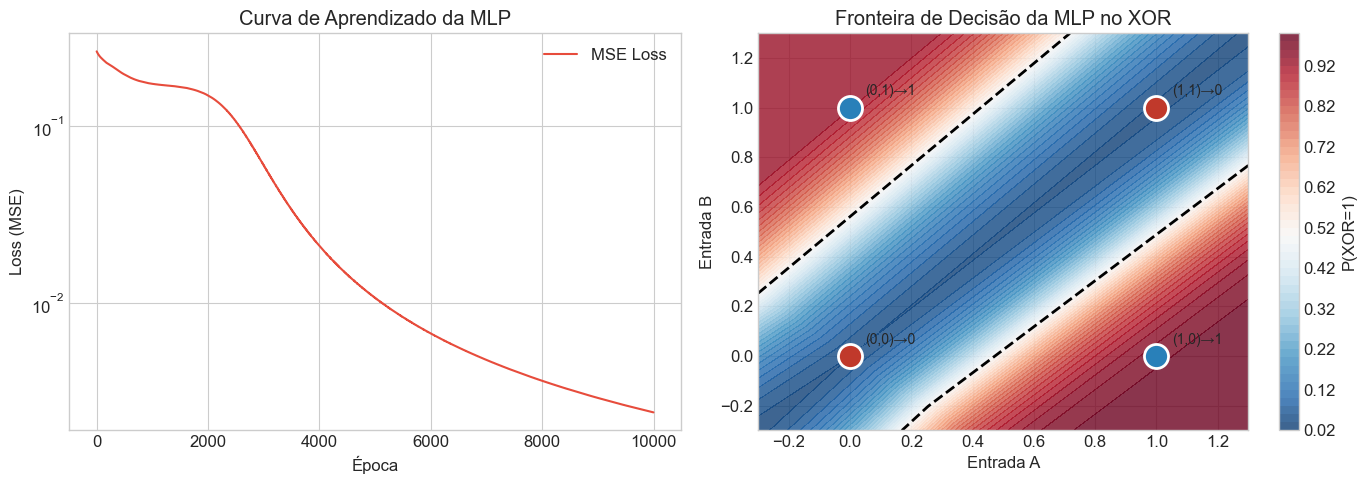

Gráficos salvos em 'mlp_xor_resultados.png'


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Curva de Aprendizado (Loss) ──
ax1 = axes[0]
ax1.plot(mlp.historico_loss_, color='#e74c3c', linewidth=1.5, label='MSE Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Curva de Aprendizado da MLP')
ax1.legend()
ax1.set_yscale('log')  # Escala log para melhor visualização

# ── Gráfico 2: Fronteira de Decisão ──
ax2 = axes[1]

# Criar grade de pontos
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 300),
                      np.linspace(-0.3, 1.3, 300))
grade = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.prever_probabilidade(grade).reshape(xx.shape)

# Plotar fundo de probabilidades
contour = ax2.contourf(xx, yy, Z, levels=50,
                        cmap='RdBu_r', alpha=0.8, vmin=0, vmax=1)
plt.colorbar(contour, ax=ax2, label='P(XOR=1)')

# Fronteira de decisão (limiar = 0.5)
ax2.contour(xx, yy, Z, levels=[0.5], colors='black',
             linewidths=2, linestyles='--')

# Plotar os 4 pontos do XOR
cores_pts = ['#c0392b' if y == 0 else '#2980b9' for y in y_xor]
for i, (x, y, c) in enumerate(zip(X_xor, y_xor, cores_pts)):
    ax2.scatter(x[0], x[1], color=c, s=300, zorder=5,
                edgecolors='white', linewidths=2)
    ax2.annotate(f'({int(x[0])},{int(x[1])})→{int(y)}',
                 xy=(x[0], x[1]), xytext=(x[0]+0.05, x[1]+0.05), fontsize=10)

ax2.set_xlabel('Entrada A')
ax2.set_ylabel('Entrada B')
ax2.set_title('Fronteira de Decisão da MLP no XOR')

plt.tight_layout()
plt.savefig('mlp_xor_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficos salvos em 'mlp_xor_resultados.png'")

## 8. Pesos Finais da Rede

In [48]:
print("Pesos finais da MLP após o treinamento:")
print("=" * 45)
print(f"\nW1 (Entrada → Oculta), shape {mlp.W1.shape}:")
print(np.round(mlp.W1, 4))
print(f"\nb1 (Bias da Oculta):")
print(np.round(mlp.b1, 4))
print(f"\nW2 (Oculta → Saída), shape {mlp.W2.shape}:")
print(np.round(mlp.W2, 4))
print(f"\nb2 (Bias da Saída):")
print(np.round(mlp.b2, 4))

Pesos finais da MLP após o treinamento:

W1 (Entrada → Oculta), shape (2, 4):
[[ 1.7429 -1.04    1.8584  2.6301]
 [-1.951  -1.3022 -1.8065 -2.6301]]

b1 (Bias da Oculta):
[[0.     0.     1.8065 0.    ]]

W2 (Oculta → Saída), shape (4, 1):
[[ 1.716 ]
 [-0.6032]
 [-3.1262]
 [ 3.6247]]

b2 (Bias da Saída):
[[2.4728]]
